In [ ]:
#https://www.kaggle.com/datasets/rakannimer/air-passengers

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns # Visualization
import matplotlib.pyplot as plt # Visualization

from sklearn.metrics import mean_absolute_error, mean_squared_error
import math


net_df = pd.read_csv("/Users/Admin/Desktop/Predictive-Analysis/AirPassengers.csv")

net_df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
net_df.shape

(144, 4)

In [ ]:
net_df.isna().sum()

Month                   0
#Passengers             0
#Passengers_diff_1      0
#Passengers_diff_2      0
forecast_manual       129
SMA_3                   2
pandas_SMA_3            2
dtype: int64

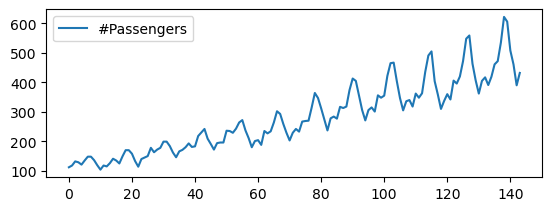

In [ ]:
net_df[["#Passengers"]].plot(subplots=True, layout=(2,1));

## 1) Check stationary

C:\Users\Admin\AppData\Local\Temp\ipykernel_10756\859539448.py:28: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(net_df ["#Passengers"].values, ax=ax[1])


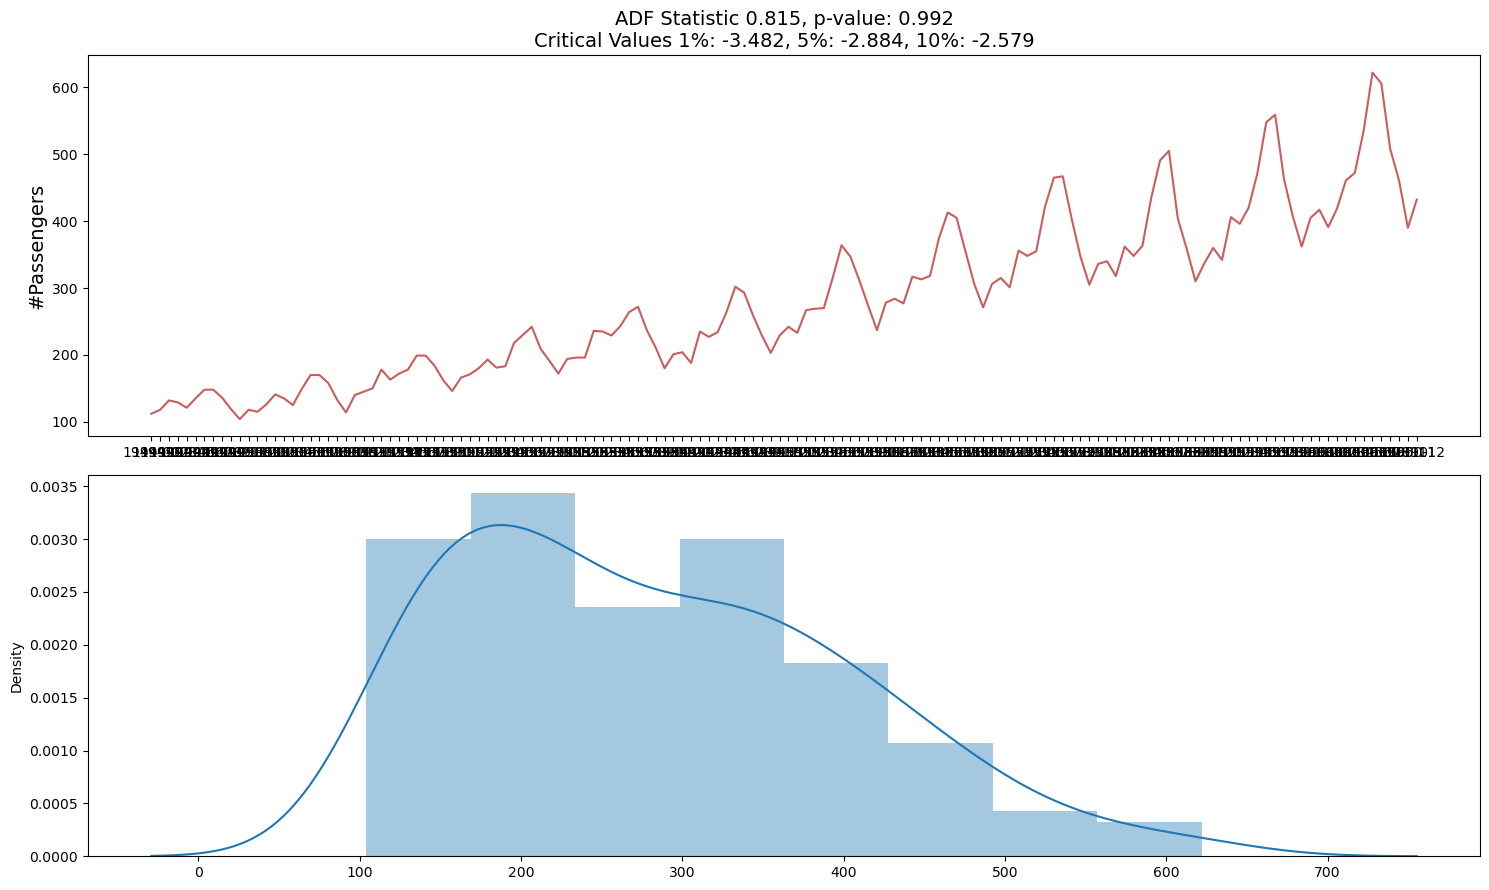

In [ ]:
from statsmodels.tsa.stattools import adfuller

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 9))

def visualize_adfuller_results(series, title, ax):
    result = adfuller(series)
    significance_level = 0.05
    adf_stat = result[0]
    p_val = result[1]
    crit_val_1 = result[4]['1%']
    crit_val_5 = result[4]['5%']
    crit_val_10 = result[4]['10%']

    if (p_val < significance_level) & ((adf_stat < crit_val_1)):
        linecolor = 'forestgreen'
    elif (p_val < significance_level) & (adf_stat < crit_val_5):
        linecolor = 'gold'
    elif (p_val < significance_level) & (adf_stat < crit_val_10):
        linecolor = 'orange'
    else:
        linecolor = 'indianred'
    sns.lineplot(x=net_df ["Month"].values, y=series, ax=ax, color=linecolor)

    ax.set_title(f'ADF Statistic {adf_stat:0.3f}, p-value: {p_val:0.3f}\nCritical Values 1%: {crit_val_1:0.3f}, 5%: {crit_val_5:0.3f}, 10%: {crit_val_10:0.3f}', fontsize=14)
    ax.set_ylabel(ylabel=title, fontsize=14)

visualize_adfuller_results(net_df ["#Passengers"].values, '#Passengers', ax[0])
sns.distplot(net_df ["#Passengers"].values, ax=ax[1])

plt.tight_layout()
plt.show()

- #Passengers are non-stationary since p-value > 0.05

## 2)Finding the value of the d parameter
### Differencing Transform of absolute values

In [ ]:
# First Order Differencing
ts_diff = np.diff(net_df ["#Passengers"])
net_df ["#Passengers_diff_1"] = np.append([0], ts_diff)

# Second Order Differencing
ts_diff = np.diff(net_df ["#Passengers_diff_1"])
net_df ["#Passengers_diff_2"] = np.append([0], ts_diff)

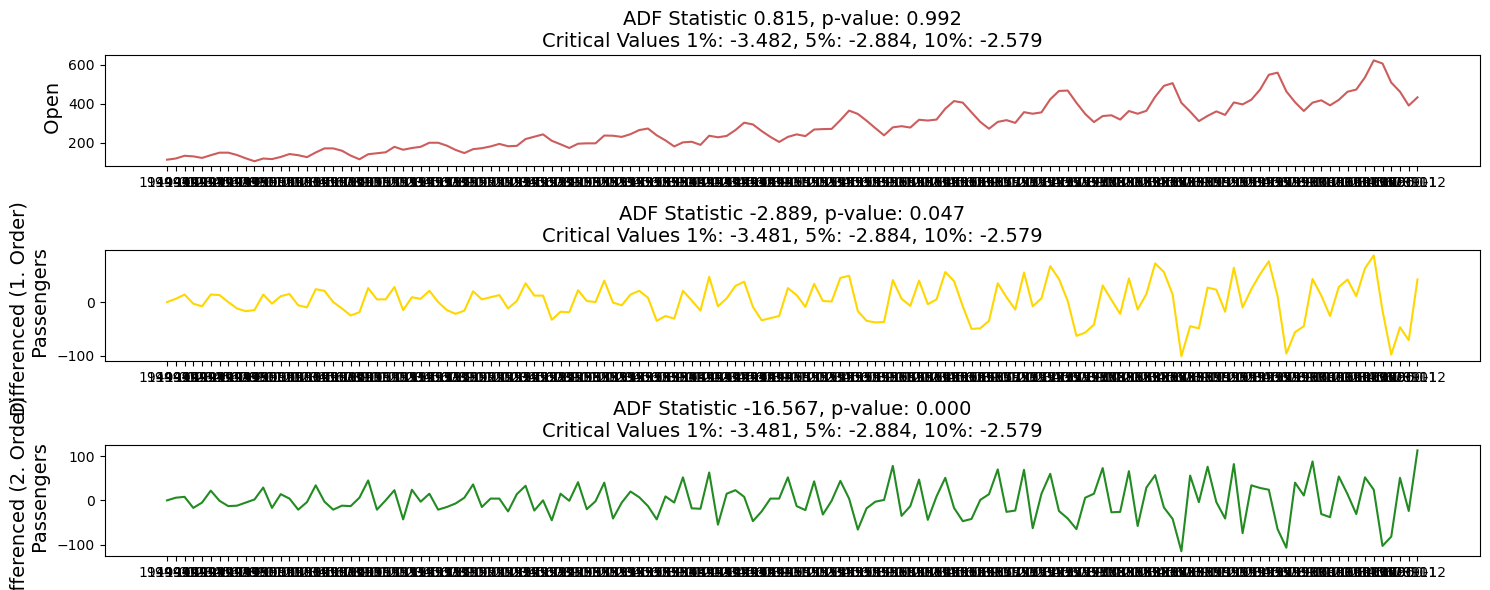

In [ ]:
f, ax = plt.subplots(nrows=3, ncols=1, figsize=(15, 6))

visualize_adfuller_results(net_df ["#Passengers"], ' Open', ax[0])
visualize_adfuller_results(net_df ["#Passengers_diff_1"], 'Differenced (1. Order) \n Passengers', ax[1])
visualize_adfuller_results(net_df ["#Passengers_diff_2"], 'Differenced (2. Order) \n Passengers', ax[2])

plt.tight_layout()
plt.show()

- First-order differencing we have fewer noises in the data while after 1st order there is an increase in the noise. So we can select 1st order differencing for our mode


## Autocorrelation plot

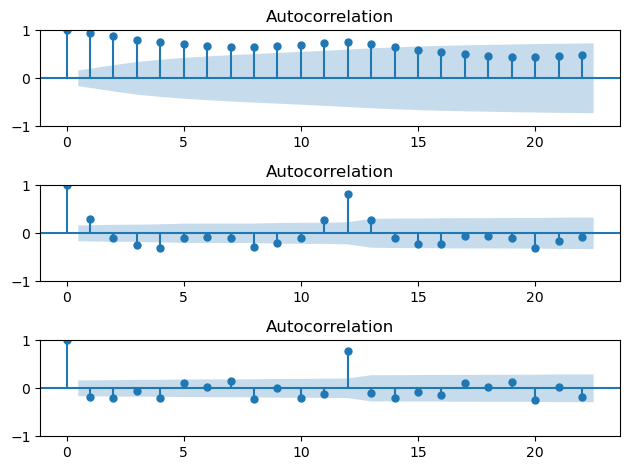

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, (ax1, ax2, ax3) = plt.subplots(3)

plot_acf(net_df["#Passengers"], ax=ax1)

plot_acf(net_df["#Passengers"].diff().dropna(), ax=ax2)

plot_acf(net_df["#Passengers"].diff().diff().dropna(), ax=ax3)

plt.tight_layout()
plt.show()

- In second-order differencing the immediate lag has gone on the negative side, representing that in the second-order the series has become over the difference


## 3)Finding the value of the p parameter

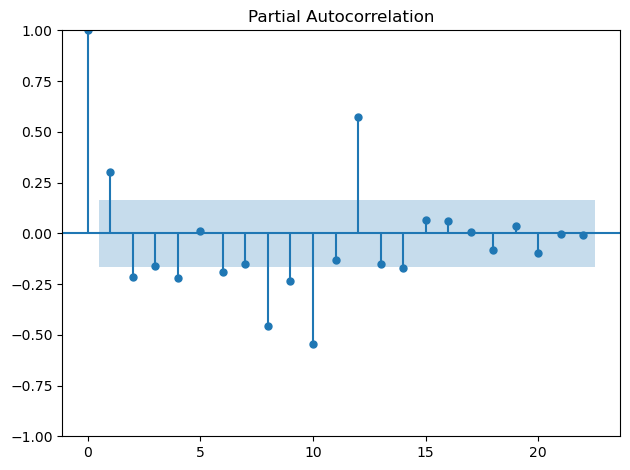

In [ ]:
# Using the PACF plot we can take the order of AR terms to be equal to the lags that can cross a significance limit.
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(net_df["#Passengers"].diff().dropna())
plt.tight_layout()
plt.show()

- The first lag is significantly out of the limit and the second one is also out of the significant limit but it is not that far so we can select the order of the p as 1 or 2


## 3)Finding the value of the q parameter

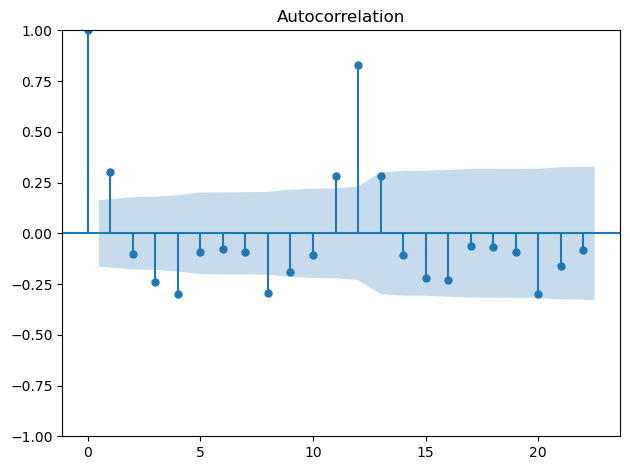

In [ ]:
# To find out the value of q we can use the ACF plot. Which will tell us how much moving average is required to remove the autocorrelation from the stationary time series.
plot_acf(net_df["#Passengers"].diff().dropna())
plt.tight_layout()
plt.show()

- We can see that 2 of the lags are out of the significance limit so we can say that the optimal value of our q (MA) is 2


In [ ]:
# Split training and testing dataset
train_data, test_data = net_df[0:int(len(net_df)*0.9)], net_df[int(len(net_df)*0.9):]

train_arima = train_data["#Passengers"]
test_arima = test_data["#Passengers"]


print(train_arima.shape)
print(test_arima.shape)

(129,)
(15,)


## 4)Building ARIMA model


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math


model = ARIMA(train_arima, order=(1,1,2))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  129
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -606.843
Date:                Thu, 03 Oct 2024   AIC                           1221.685
Time:                        20:15:28   BIC                           1233.094
Sample:                             0   HQIC                          1226.321
                                - 129                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5540      0.118      4.681      0.000       0.322       0.786
ma.L1         -0.2960      0.106     -2.799      0.005      -0.503      -0.089
ma.L2         -0.5093      0.073     -6.983      0.0

## 5)Make time series predictions

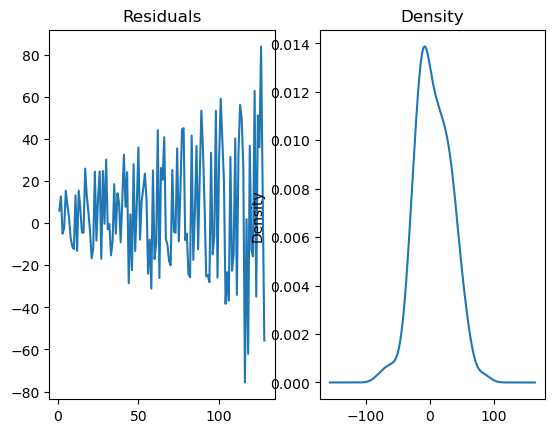

In [ ]:
# Checking the residuals. If the model is good, its residuals should look like white noise
import matplotlib.pyplot as plt
residuals = model_fit.resid[1:]
fig, ax = plt.subplots(1,2)
residuals.plot(title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])
plt.show()

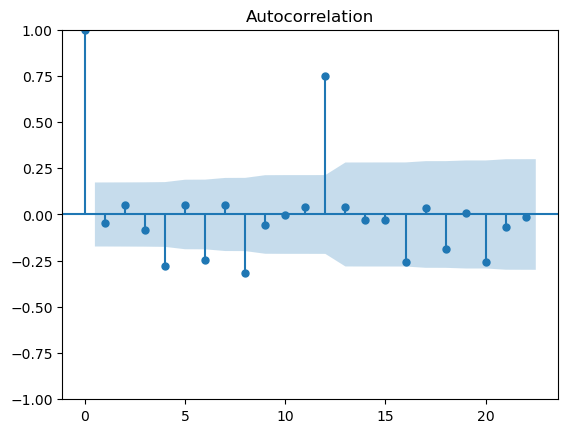

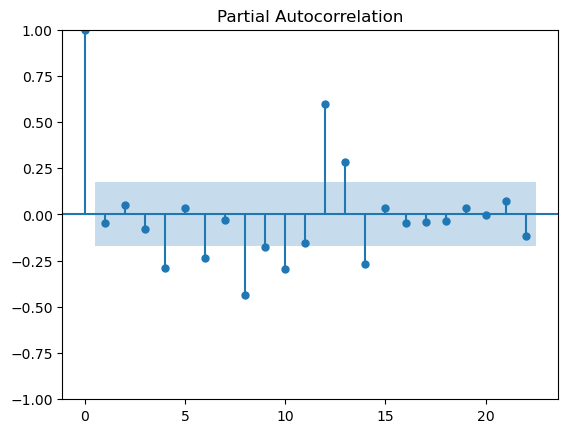

In [ ]:
acf_res = plot_acf(residuals)

pacf_res = plot_pacf(residuals)

<Axes: >

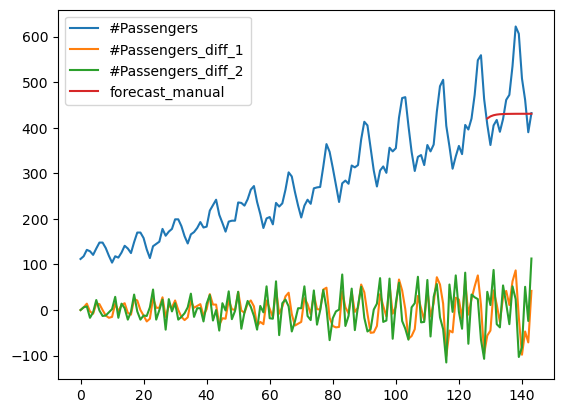

In [ ]:
forecast_test = model_fit.forecast(len(test_arima))

net_df['forecast_manual'] = [None]*len(train_arima) + list(forecast_test)

net_df.plot()

## Model Evaluation


In [ ]:
# report performance
mse = mean_squared_error(test_arima, forecast_test)
print('MSE: '+str(mse))
mae = mean_absolute_error(test_arima, forecast_test)
print('MAE: '+str(mae))
rmse = math.sqrt(mean_squared_error(test_arima, forecast_test))
print('RMSE: '+str(rmse))

MSE: 6401.81682196112
MAE: 56.8993134645802
RMSE: 80.01135433150172


## 6) Auto-fit the ARIMA model

In [ ]:
import pmdarima as pm

auto_arima = pm.auto_arima(train_arima, stepwise=False, seasonal=False)
auto_arima

ARIMA(order=(2, 1, 2), scoring_args={}, suppress_warnings=True)

In [ ]:
model = ARIMA(train_arima, order=(2,1,2))
model_fit = model.fit()

<Axes: >

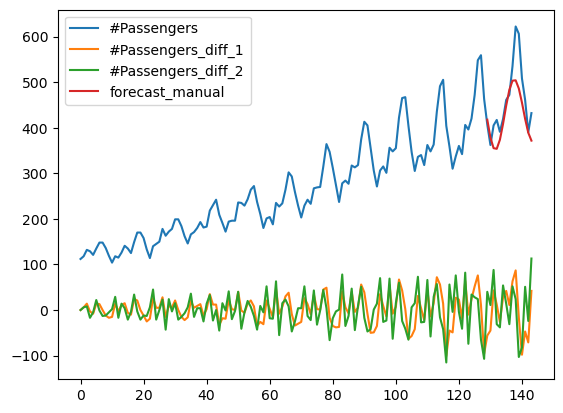

In [ ]:
forecast_test = model_fit.forecast(len(test_arima))

net_df['forecast_manual'] = [None]*len(train_arima) + list(forecast_test)

net_df.plot()

In [ ]:
# report performance
mse = mean_squared_error(test_arima, forecast_test)
print('MSE: '+str(mse))
mae = mean_absolute_error(test_arima, forecast_test)
print('MAE: '+str(mae))
rmse = math.sqrt(mean_squared_error(test_arima, forecast_test))
print('RMSE: '+str(rmse))

MSE: 3009.3865904843456
MAE: 41.20191973284694
RMSE: 54.85787628485399


# Moving Average

## 1)Simple Moving Average(SMA):
- This domain uses a sliding window to take the average over a set number of time periods. It is an equally weighted mean of the previous n data

In [ ]:
for i in range(0,net_df.shape[0]-2):
    net_df.loc[net_df.index[i+2],'SMA_3'] = np.round(((net_df.iloc[i,1]+ net_df.iloc[i+1,1] +net_df.iloc[i+2,1])/3),1)

net_df.head()

,Month,#Passengers,#Passengers_diff_1,#Passengers_diff_2,forecast_manual,SMA_3
0,1949-01,112,0,0,NaN,NaN
1,1949-02,118,6,6,NaN,NaN
2,1949-03,132,14,8,NaN,120.7
3,1949-04,129,-3,-17,NaN,126.3
4,1949-05,121,-8,-5,NaN,127.3


In [ ]:
## SMA pandas functions
net_df['pandas_SMA_3'] = np.round(net_df.iloc[:,1].rolling(window=3).mean(),1)
net_df.head()

,Month,#Passengers,#Passengers_diff_1,#Passengers_diff_2,forecast_manual,SMA_3,pandas_SMA_3
0,1949-01,112,0,0,NaN,NaN,NaN
1,1949-02,118,6,6,NaN,NaN,NaN
2,1949-03,132,14,8,NaN,120.7,120.7
3,1949-04,129,-3,-17,NaN,126.3,126.3
4,1949-05,121,-8,-5,NaN,127.3,127.3


In [ ]:
#
sma_30 = net_df['#Passengers'].rolling(window=30).mean()
sma_30

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
139    432.566667
140    437.433333
141    441.200000
142    442.100000
143    442.000000
Name: #Passengers, Length: 144, dtype: float64

In [ ]:
#To mprove our plot appearence ,we can use a pre-defined style
plt.style.use('fivethirtyeight')

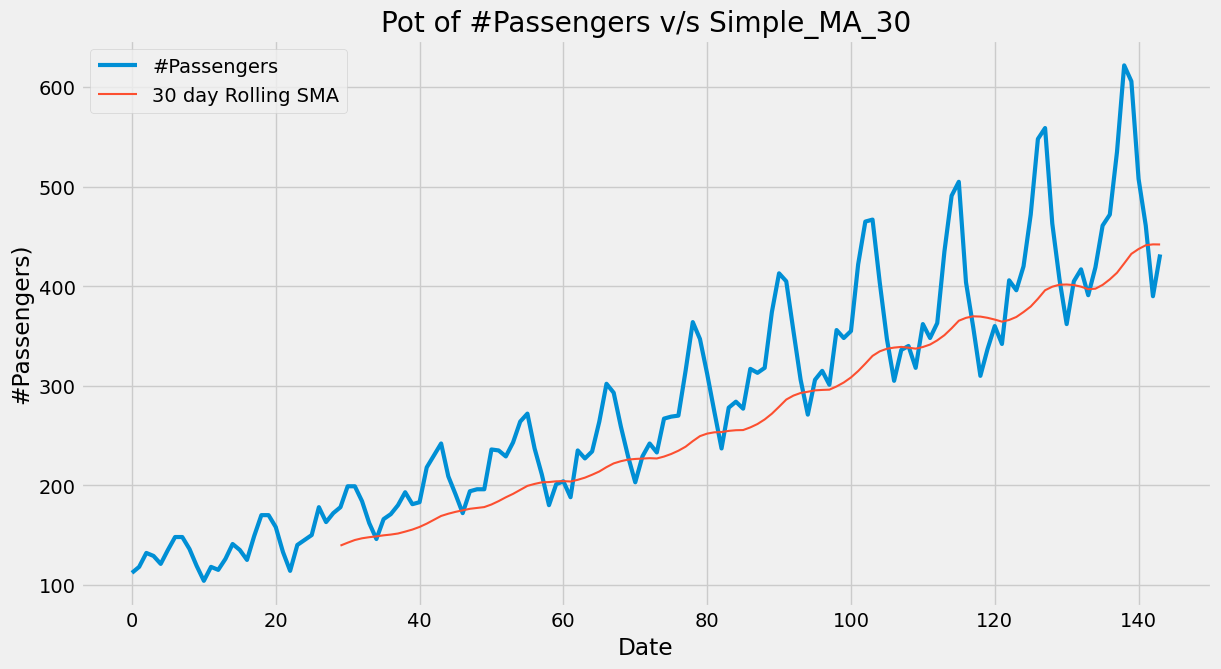

In [ ]:
#Our Chart size
plt.figure(figsize = (13,7))

#Plotting 'Adj Close' Price and SMA_50 lines
plt.plot(net_df['#Passengers'],label='#Passengers',linewidth=3)
plt.plot(sma_30,label='30 day Rolling SMA',linewidth=1.5)

#Adding title, labels on the axis:
#Legend on the left-upper corner
plt.xlabel('Date')
plt.ylabel('#Passengers)')
plt.title('Pot of #Passengers v/s Simple_MA_30')
plt.legend()

## 2)Cumulative Moving Average(CMA)
- Cumulative moving average considers all prior observations. CMA is not a very good technique for analyzing trends and smoothing out the data.

In [ ]:
cma_30 = net_df['#Passengers'].expanding(min_periods=30).mean()
cma_30

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
139    275.514286
140    277.163121
141    278.457746
142    279.237762
143    280.298611
Name: #Passengers, Length: 144, dtype: float64

In [ ]:
#So, we can see that the last row value of CMA is just the average(mean) of all the previous data up until the last data point.
net_df['#Passengers'].mean()

280.2986111111111

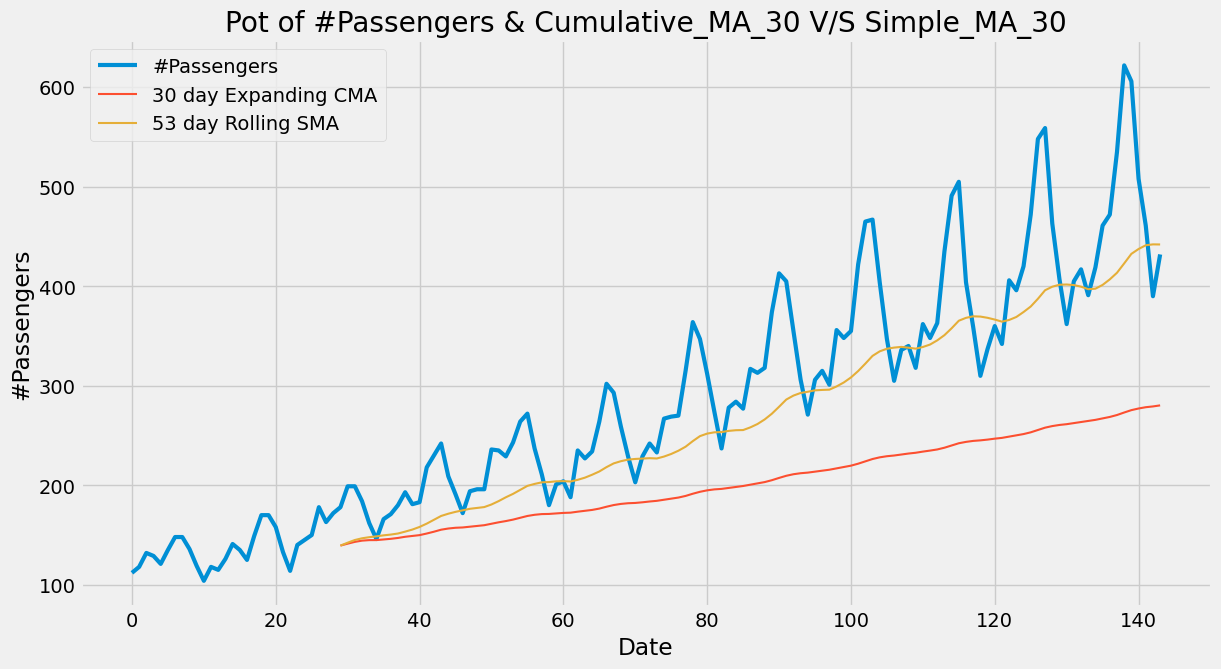

In [ ]:
plt.style.use('fivethirtyeight')
#Our Chart size
plt.figure(figsize = (13,7))

#Plotting 'Adj Close' Price and SMA_50 lines
plt.plot(net_df['#Passengers'],label='#Passengers',linewidth=3)
plt.plot(cma_30,label='30 day Expanding CMA',linewidth=1.5)
plt.plot(sma_30,label='53 day Rolling SMA',linewidth=1.5)

#Adding title, labels on the axis:
#Legend on the left-upper corner
plt.xlabel('Date')
plt.ylabel('#Passengers')
plt.title('Pot of #Passengers & Cumulative_MA_30 V/S Simple_MA_30')
plt.legend()

## 3)Exponential Moving Average(EMA)
- Exponential moving average gives more weight to the recent prices and as a result of which, it can be a better model or better capture the movement of the trend in a faster way. EMA's reaction is directly proportional to the pattern of the data.

In [ ]:
ema_30 = net_df['#Passengers'].ewm(span=30,adjust=False).mean()
ema_30

0      112.000000
1      112.387097
2      113.652445
3      114.642610
4      115.052764
          ...    
139    442.347539
140    446.583182
141    447.513299
142    443.802764
143    443.041295
Name: #Passengers, Length: 144, dtype: float64

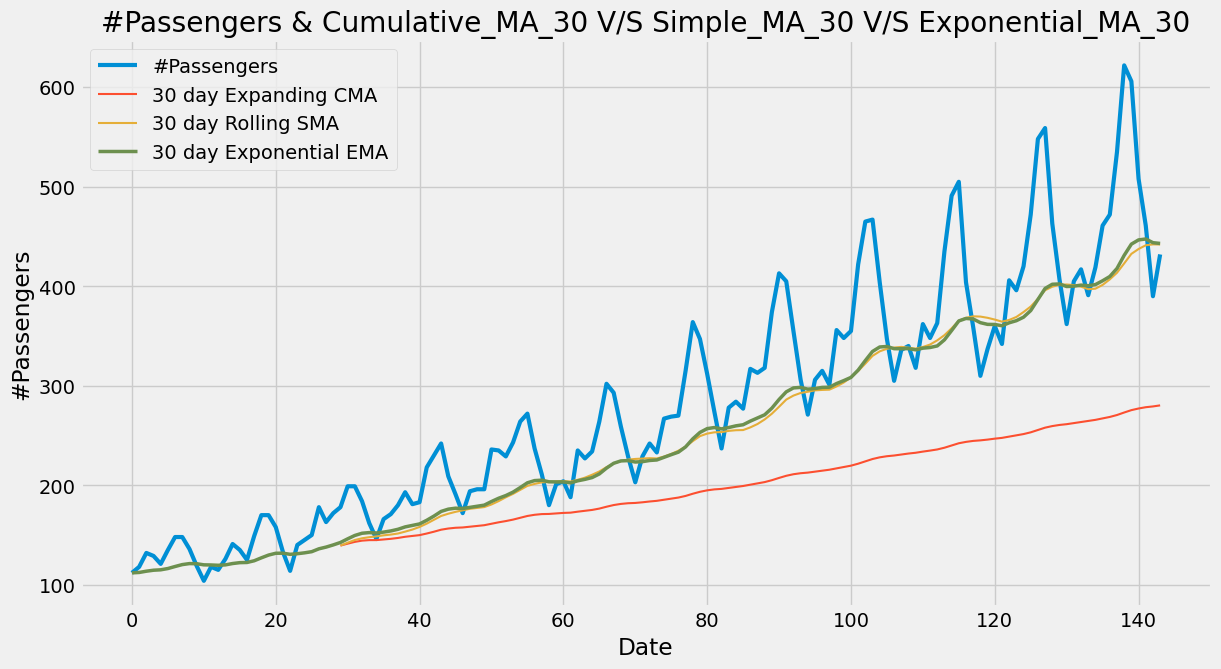

In [ ]:
plt.style.use('fivethirtyeight')
#Our Chart size
plt.figure(figsize = (13,7))

#Plotting 'Adj Close' Price and SMA_50 lines
plt.plot(net_df['#Passengers'],label='#Passengers',linewidth=3)
plt.plot(cma_30,label='30 day Expanding CMA',linewidth=1.5)
plt.plot(sma_30,label='30 day Rolling SMA',linewidth=1.5)
plt.plot(ema_30,label='30 day Exponential EMA',linewidth=2.5)

#Adding title, labels on the axis:
#Legend on the left-upper corner
plt.xlabel('Date')
plt.ylabel('#Passengers')
plt.title('#Passengers & Cumulative_MA_30 V/S Simple_MA_30 V/S Exponential_MA_30')
plt.legend()

#  Exponential smoothing model
## 1)  Simple Exponential Smoothing

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# create class
model_ses = SimpleExpSmoothing(train_arima)
alpha = 0.2
# fit model
model_fit_ses = model_ses.fit(smoothing_level = alpha, optimized = False)

In [ ]:
# make prediction
forecast_ses = model_fit_ses.forecast(15)

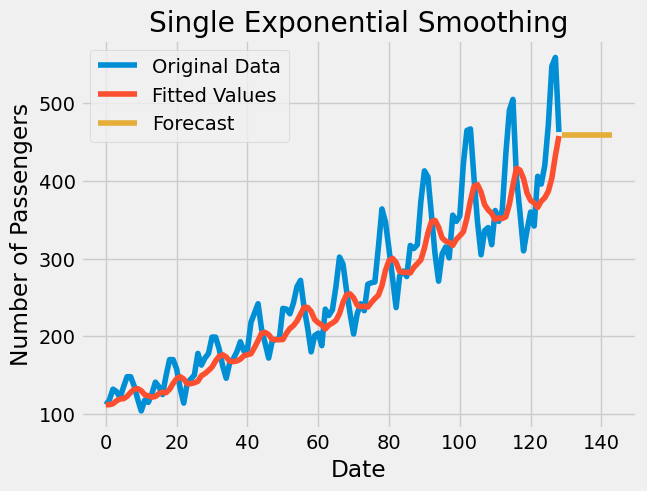

In [ ]:
plt.plot(train_arima, label='Original Data')
plt.plot(model_fit_ses.fittedvalues, label='Fitted Values')
plt.plot(forecast_ses, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

In [ ]:
forecast_ses

129    458.903531
130    458.903531
131    458.903531
132    458.903531
133    458.903531
134    458.903531
135    458.903531
136    458.903531
137    458.903531
138    458.903531
139    458.903531
140    458.903531
141    458.903531
142    458.903531
143    458.903531
dtype: float64

## 2) Double Exponential Smoothing

In [ ]:
from statsmodels.tsa.api import Holt

model_double = Holt(train_arima)
model_double_fit = model_double.fit()

In [ ]:
forecast_double = model_double_fit.forecast(15)
print(forecast_double)

129    468.454963
130    473.405292
131    478.355621
132    483.305949
133    488.256278
134    493.206607
135    498.156936
136    503.107265
137    508.057593
138    513.007922
139    517.958251
140    522.908580
141    527.858908
142    532.809237
143    537.759566
dtype: float64


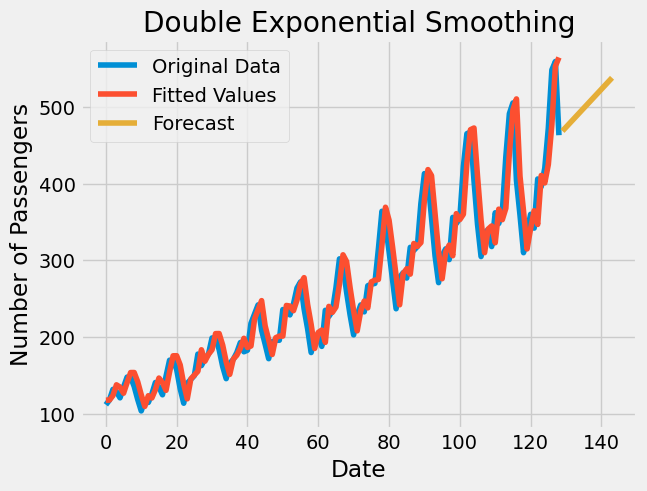

In [ ]:
plt.plot(train_arima, label='Original Data')
plt.plot(model_double_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_double, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Double Exponential Smoothing')
plt.legend()
plt.show()

## 3)Holt-Winter’s Seasonal Smoothing

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing

# Create an instance of ExponentialSmoothing class
model_triple = ExponentialSmoothing(
    train_arima, seasonal_periods=12, trend='add', seasonal='add')

# Fit the model to the data
model_triple_fit = model_triple.fit()

In [ ]:
forecast_triple = model_triple_fit.forecast(15)
print(forecast_triple)

129    405.047147
130    357.835338
131    388.075014
132    409.883172
133    391.433374
134    451.778642
135    439.598706
136    460.371339
137    514.793313
138    586.537135
139    593.041872
140    480.930929
141    435.111783
142    387.899974
143    418.139650
dtype: float64


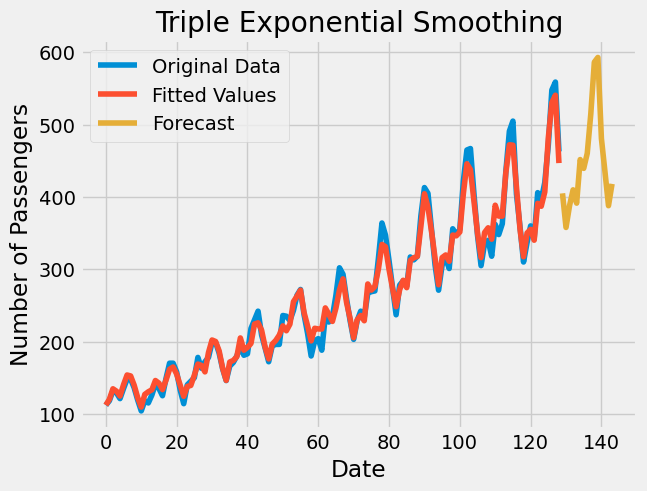

In [ ]:
plt.plot(train_arima, label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()